In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [9]:
# ========== функция 1 ==========
def f1(x, y):
    return np.log(1 + x**2 + y**2)

def grad_f1(x, y):
    denom = 1 + x**2 + y**2
    return np.array([2*x / denom, 2*y / denom])

In [10]:
# ========== функция 2 ==========
def f2(x, y):
    return np.sin(x*y) + np.cos(x + y)

def grad_f2(x, y):
    return np.array([
        y*np.cos(x*y) - np.sin(x + y),   # df/dx
        x*np.cos(x*y) - np.sin(x + y)    # df/dy
    ])

In [11]:
def gradient_descent(f, grad_f, start, lr=0.1, steps=50):
    path = [np.array(start)]
    x, y = start
    for _ in range(steps):
        gx, gy = grad_f(x, y)
        x -= lr * gx
        y -= lr * gy
        path.append(np.array([x, y]))
    return np.array(path)

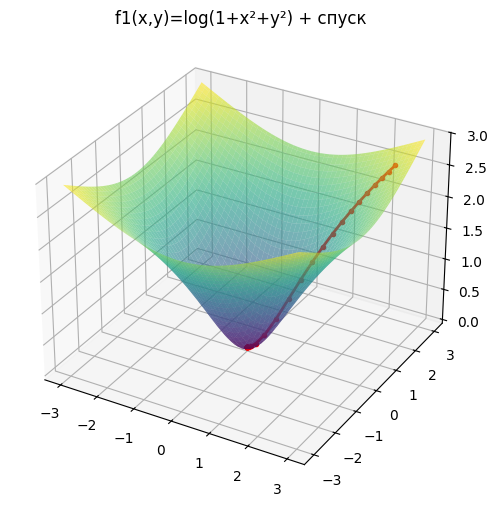

In [12]:
# ==== 3D-поверхность f1 ====
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = f1(X, Y)

path1 = gradient_descent(f1, grad_f1, start=[2.5, 2.5], lr=0.3, steps=30)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)
ax.plot(path1[:,0], path1[:,1], f1(path1[:,0], path1[:,1]), 'r.-', lw=2)
ax.set_title('f1(x,y)=log(1+x²+y²) + спуск')
plt.show()

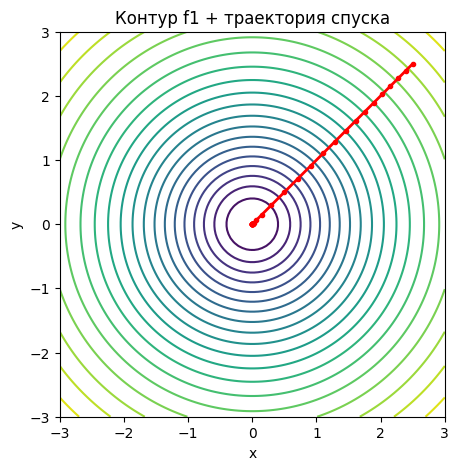

In [13]:
plt.figure(figsize=(6,5))
plt.contour(X, Y, Z, levels=20)
plt.plot(path1[:,0], path1[:,1], 'r.-', lw=2)
plt.title('Контур f1 + траектория спуска')
plt.xlabel('x'); plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.show()

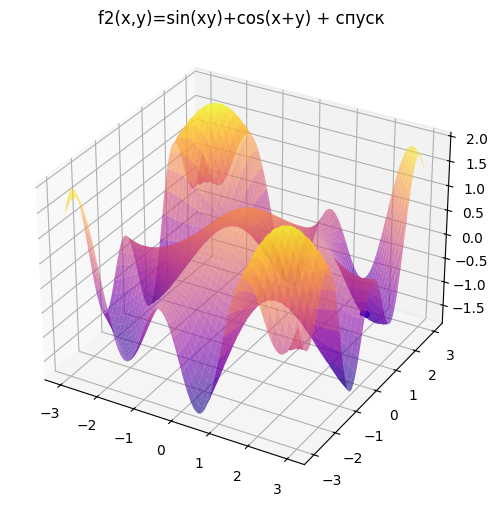

In [14]:
# ==== 3D-поверхность f2 ====
Z2 = f2(X, Y)
path2 = gradient_descent(f2, grad_f2, start=[2, 2], lr=0.1, steps=40)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z2, cmap='plasma', alpha=0.6)
ax.plot(path2[:,0], path2[:,1], f2(path2[:,0], path2[:,1]), 'b.-', lw=2)
ax.set_title('f2(x,y)=sin(xy)+cos(x+y) + спуск')
plt.show()


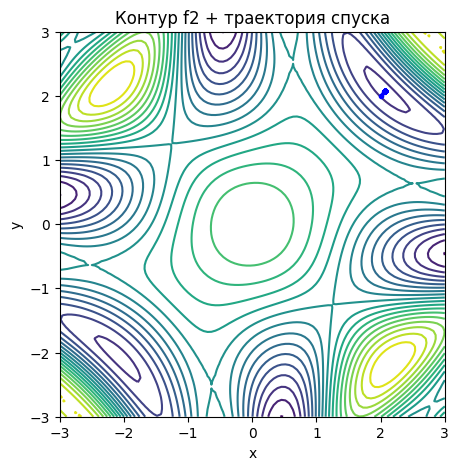

In [15]:
plt.figure(figsize=(6,5))
plt.contour(X, Y, Z2, levels=20)
plt.plot(path2[:,0], path2[:,1], 'b.-', lw=2)
plt.title('Контур f2 + траектория спуска')
plt.xlabel('x'); plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.show()

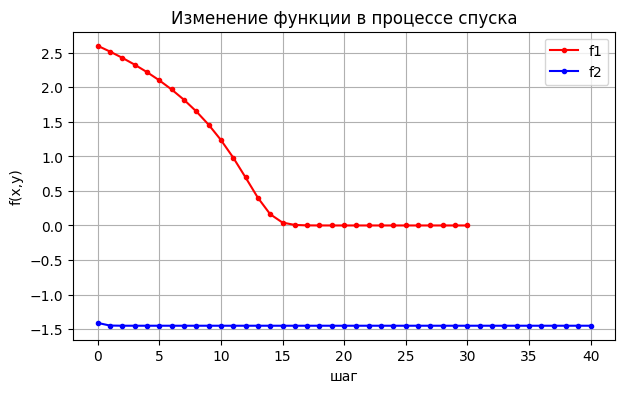

In [16]:
# ==== значения по шагам ====
steps1 = np.arange(len(path1))
vals1  = f1(path1[:,0], path1[:,1])

steps2 = np.arange(len(path2))
vals2  = f2(path2[:,0], path2[:,1])

plt.figure(figsize=(7,4))
plt.plot(steps1, vals1, 'r.-', label='f1')
plt.plot(steps2, vals2, 'b.-', label='f2')
plt.xlabel('шаг')
plt.ylabel('f(x,y)')
plt.title('Изменение функции в процессе спуска')
plt.legend()
plt.grid(True)
plt.show()